# Analyse complète — Avis Abritel (3 sources)

**Périmètre des données**  
- Sources : script `1_pipeline.py` — **Google Play** (package Android `com.vacationrentals.homeaway`), **App Store iOS** (API RSS Apple), **Trustpilot** (`abritel.fr`).  
- Période : du **1er janvier 2025** au jour du scraping (jour civil **Europe/Paris**), via pagination.  
- Notes **1 à 5** conservées, toutes sources confondues.  
- Enrichissement : colonnes **Catégorie** (8 catégories) et **Gravité** par **mots-clés** (règles dans `1_pipeline.py`) — ce n'est pas du machine learning ; l'ordre des règles fixe la catégorie retenue.

**Fichier** : `data/avis_enrichis.csv` (UTF-8-SIG, une ligne = un avis).  
**Usage Power BI** : importer ce CSV, typer `date` en date/heure, `note` en entier, recréer les mêmes mesures que dans la section *Indicateurs clés* ci-dessous.

---

In [1]:
# Configuration : chemins, style des graphiques, affichage des tableaux
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Graphiques lisibles pour support PDF / soutenance
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "figure.dpi": 120,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}".rstrip("0").rstrip("."))

DATA_PATH = Path("data") / "avis_enrichis.csv"

COLONNES_ATTENDUES = ["date", "note", "texte", "source", "Catégorie", "Gravité"]
ORDRE_GRAVITE = ["Haute", "Moyenne", "Basse"]
ORDRE_NOTES = [1, 2, 3, 4, 5]

## 1. Chargement et schéma

On charge le CSV en **UTF-8-SIG** et on parse la colonne `date`. Si le fichier est absent, exécuter d’abord : `uv run python 1_pipeline.py`.


In [2]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Fichier introuvable : {DATA_PATH.resolve()}\n"
        "Lance le pipeline depuis la racine du projet : uv run python 1_pipeline.py"
    )

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

manquantes = [c for c in COLONNES_ATTENDUES if c not in df.columns]
if manquantes:
    raise ValueError(f"Colonnes manquantes : {manquantes}. Colonnes lues : {list(df.columns)}")

# Typage explicite (utile pour recoder pareil dans Power BI)
df["note"] = pd.to_numeric(df["note"], errors="coerce").astype("Int64")
df["texte"] = df["texte"].astype(str)

print("Dimensions :", df.shape[0], "lignes ×", df.shape[1], "colonnes")
print("Période couverte :", df["date"].min(), "→", df["date"].max())
df.dtypes.to_frame("dtype")

Dimensions : 441 lignes × 6 colonnes
Période couverte : 2025-01-01 12:37:19 → 2026-04-11 18:09:14


,dtype
date,datetime64[us]
note,Int64
texte,str
source,str
Catégorie,str
Gravité,str


In [3]:
df.head(8)

,date,note,texte,source,Catégorie,Gravité
0,2026-04-11 18:09:14,4,comment recevoir toutes les infos en français ??,Google Play,Localisation / Langue,Basse
1,2026-04-11 07:18:47,1,"Bonjour, - Impossible de voir le paiement (le montant...) qui est en cours de validation - Les mails se mélangent, p...",Google Play,Financier,Haute
2,2026-04-10 12:52:15,5,utilisateur depuis de nombreuses années. toujours satisfait des locations estivales.,Google Play,Qualité du bien,Basse
3,2026-04-10 09:49:23,4,"très facile d'utilisation, petit bémol la plateforme de paiement est en anglais et pas facile pour moi qui ne maîtri...",Google Play,Localisation / Langue,Basse
4,2026-04-09 11:34:57,5,enfin des locations abordable 🥰,Google Play,Qualité du bien,Basse
5,2026-04-07 22:35:40,1,impossible d'avoir l'application en français.,Google Play,Localisation / Langue,Haute
6,2026-04-07 10:53:02,1,"Depuis maintenant plusieurs mois, quand je veux ouvrir l'application Abritel, je suis dirigé vers une autre appli qu...",Google Play,Localisation / Langue,Haute
7,2026-04-06 20:21:30,1,bonjour. comment on change la langue de l application ? celle ci est paramétré en allemand et je cherche en français,Google Play,Localisation / Langue,Haute


## 2. Contrôle qualité

Vérifications **minimales** pour des indicateurs fiables : doublons, valeurs manquantes, cohérence des notes (doivent être entre 1 et 5 après le pipeline).

In [4]:
# Doublons : même date + même note + même texte (avis strictement identique)
dup_mask = df.duplicated(subset=["date", "note", "texte"], keep=False)
n_dup = int(dup_mask.sum())
print(f"Lignes faisant partie d'un doublon (date+note+texte) : {n_dup}")

# Valeurs manquantes par colonne
na_pct = (df.isna().mean() * 100).round(2)
print("\n% de valeurs manquantes par colonne :")
print(na_pct.to_string())

# Dates non parsées
n_bad_dates = int(df["date"].isna().sum())
if n_bad_dates:
    print(f"\nAttention : {n_bad_dates} date(s) non converties.")

# Notes hors périmètre 1–5 (anomalie)
notes_invalides = df[~df["note"].isin([1, 2, 3, 4, 5]) & df["note"].notna()]
print(f"\nLignes avec note ≠ 1,2,3 (hors NA) : {len(notes_invalides)}")
if len(notes_invalides) > 0:
    display(notes_invalides[["date", "note", "texte"]].head())

# Colonnes Catégorie / Gravité : pas de NaN pour l'analyse des effectifs
for col in ["Catégorie", "Gravité"]:
    n = df[col].isna().sum()
    print(f"NaN dans {col!r} : {int(n)}")

Lignes faisant partie d'un doublon (date+note+texte) : 0

% de valeurs manquantes par colonne :
date        0
note        0
texte       0
source      0
Catégorie   0
Gravité     0

Lignes avec note ≠ 1,2,3 (hors NA) : 0
NaN dans 'Catégorie' : 0
NaN dans 'Gravité' : 0


## 3. Indicateurs clés (KPIs) — à reproduire dans Power BI

**Définitions** (dénominateur = nombre d’avis dans le fichier, sauf mention contraire) :

| Mesure | Définition |
|--------|------------|
| N avis | `COUNTROWS` |
| Note moyenne | moyenne arithmétique de `note` (échelle 1–5) |
| % gravité Haute | part des lignes où `Gravité` = "Haute" |
| Catégorie dominante | modus de `Catégorie` |
| Période | `MIN(date)` et `MAX(date)` |


In [5]:
N = len(df)
if N == 0:
    raise ValueError("Aucun avis : impossible de calculer les KPIs.")

note_moyenne = df["note"].mean()
note_mediane = df["note"].median()
pct_haute = 100.0 * (df["Gravité"] == "Haute").sum() / N
pct_moyenne = 100.0 * (df["Gravité"] == "Moyenne").sum() / N
pct_basse = 100.0 * (df["Gravité"] == "Basse").sum() / N

cat_counts = df["Catégorie"].value_counts()
categorie_mode = cat_counts.index[0]
freq_mode = int(cat_counts.iloc[0])
pct_mode = 100.0 * freq_mode / N

kpi = pd.DataFrame(
    [
        {"Indicateur": "Nombre d'avis (n)", "Valeur": N},
        {"Indicateur": "Date minimale", "Valeur": str(df["date"].min())},
        {"Indicateur": "Date maximale", "Valeur": str(df["date"].max())},
        {"Indicateur": "Note moyenne (1–5)", "Valeur": round(float(note_moyenne), 3)},
        {"Indicateur": "Note médiane", "Valeur": float(note_mediane)},
        {"Indicateur": "% gravité Haute", "Valeur": round(pct_haute, 2)},
        {"Indicateur": "% gravité Moyenne", "Valeur": round(pct_moyenne, 2)},
        {"Indicateur": "% gravité Basse", "Valeur": round(pct_basse, 2)},
        {"Indicateur": "Catégorie la plus fréquente", "Valeur": categorie_mode},
        {"Indicateur": "Effectif de cette catégorie", "Valeur": freq_mode},
        {"Indicateur": "% de l'ensemble (catégorie dominante)", "Valeur": round(pct_mode, 2)},
    ]
)
kpi

,Indicateur,Valeur
0,Nombre d'avis (n),441
1,Date minimale,2025-01-01 12:37:19
2,Date maximale,2026-04-11 18:09:14
3,Note moyenne (1–5),2.88
4,Note médiane,3
5,% gravité Haute,43.54
6,% gravité Moyenne,6.58
7,% gravité Basse,49.89
8,Catégorie la plus fréquente,Autre
9,Effectif de cette catégorie,204


## 4. Distributions univariées

Histogrammes / barres : **notes**, **catégories**, **gravité**, **source**.


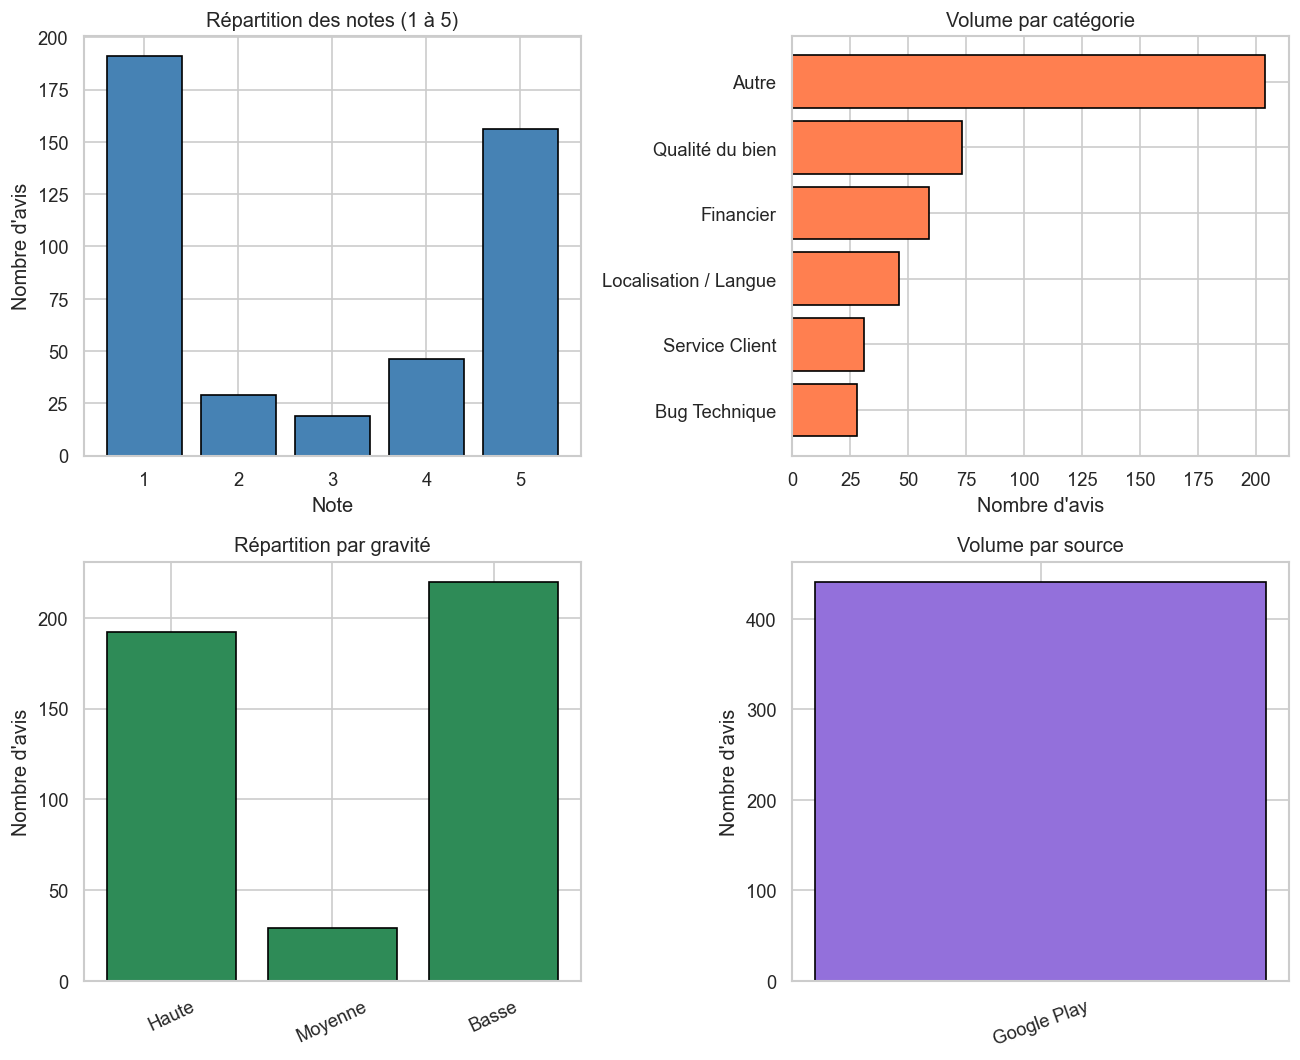

,Catégorie,Effectif,% du total
0,Autre,204,46.26
1,Qualité du bien,73,16.55
2,Financier,59,13.38
3,Localisation / Langue,46,10.43
4,Service Client,31,7.03
5,Bug Technique,28,6.35


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# Notes (échelle 1 à 5)
note_counts = df["note"].value_counts().reindex(ORDRE_NOTES, fill_value=0)
axes[0, 0].bar(
    note_counts.index.astype(str), note_counts.values, color="steelblue", edgecolor="black"
)
axes[0, 0].set_title("Répartition des notes (1 à 5)")
axes[0, 0].set_xlabel("Note")
axes[0, 0].set_ylabel("Nombre d'avis")

# Catégories (tri par effectif décroissant)
cat_counts = df["Catégorie"].value_counts()
axes[0, 1].barh(cat_counts.index[::-1], cat_counts.values[::-1], color="coral", edgecolor="black")
axes[0, 1].set_title("Volume par catégorie")
axes[0, 1].set_xlabel("Nombre d'avis")

# Gravité (ordre métier fixe : Haute → Moyenne → Basse)
g_full = df["Gravité"].value_counts().reindex(ORDRE_GRAVITE, fill_value=0)
axes[1, 0].bar(g_full.index, g_full.values, color="seagreen", edgecolor="black")
axes[1, 0].set_title("Répartition par gravité")
axes[1, 0].set_ylabel("Nombre d'avis")
axes[1, 0].tick_params(axis="x", rotation=25)

# Source
src_counts = df["source"].value_counts()
axes[1, 1].bar(
    src_counts.index.astype(str), src_counts.values, color="mediumpurple", edgecolor="black"
)
axes[1, 1].set_title("Volume par source")
axes[1, 1].set_ylabel("Nombre d'avis")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Table des fréquences (pour copier vers Excel / Power BI)
freq_table = pd.DataFrame(
    {
        "Catégorie": cat_counts.index,
        "Effectif": cat_counts.values,
        "% du total": (100 * cat_counts.values / N).round(2),
    }
)
freq_table

## 5. Analyse temporelle

Agrégation par **mois calendaire** (année-mois). Attention : les avis reflètent la date côté store, pas la date de scraping.


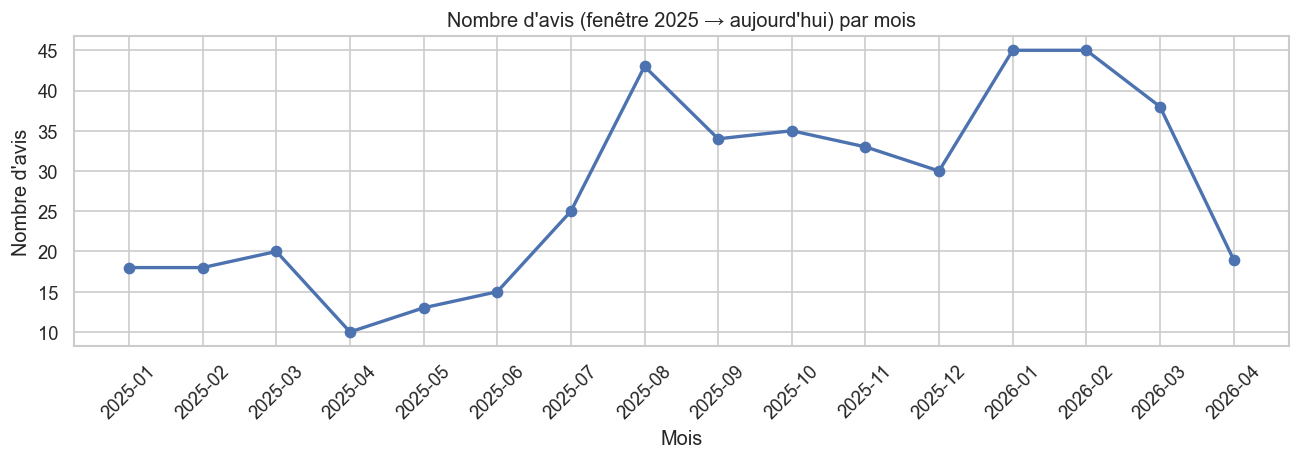

,annee_mois,nb_avis
0,2025-01,18
1,2025-02,18
2,2025-03,20
3,2025-04,10
4,2025-05,13
5,2025-06,15
6,2025-07,25
7,2025-08,43
8,2025-09,34
9,2025-10,35


In [7]:
df_time = df.dropna(subset=["date"]).copy()
df_time["annee_mois"] = df_time["date"].dt.to_period("M").astype(str)

par_mois = df_time.groupby("annee_mois", as_index=False).size()
par_mois = par_mois.rename(columns={"size": "nb_avis"})

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(par_mois["annee_mois"], par_mois["nb_avis"], marker="o", linewidth=2, markersize=6)
ax.set_title("Nombre d'avis (fenêtre 2025 → aujourd'hui) par mois")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre d'avis")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

par_mois

## 6. Tableau croisé Catégorie × Gravité

- **Effectifs** : combinaisons observées.  
- **% par ligne** : répartition de la gravité *au sein* de chaque catégorie (utile pour prioriser).  
- **% du total** : contribution de chaque cellule à l'ensemble.


In [8]:
ct = pd.crosstab(df["Catégorie"], df["Gravité"], margins=True, margins_name="Total")
ct

Gravité,Basse,Haute,Moyenne,Total
Catégorie,,,,
Autre,144,47,13,204
Bug Technique,7,17,4,28
Financier,12,40,7,59
Localisation / Langue,8,36,2,46
Qualité du bien,40,30,3,73
Service Client,9,22,0,31
Total,220,192,29,441


% de chaque gravité DANS chaque catégorie (ligne = 100%) :


Gravité,Basse,Haute,Moyenne,Total ligne (100%)
Catégorie,,,,
Autre,70.59,23.04,6.37,100
Bug Technique,25,60.71,14.29,100
Financier,20.34,67.8,11.86,100
Localisation / Langue,17.39,78.26,4.35,100
Qualité du bien,54.79,41.1,4.11,100
Service Client,29.03,70.97,0,100


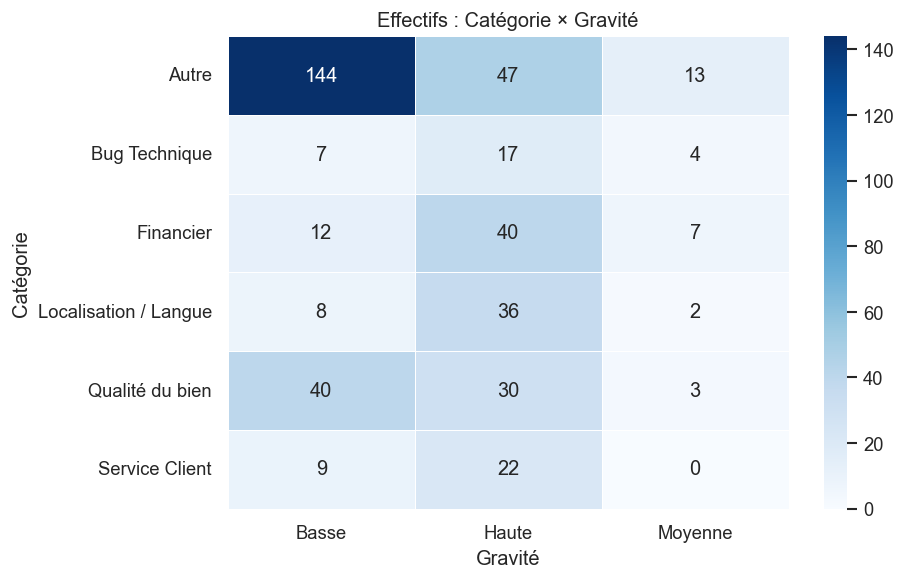

In [9]:
# % par ligne (sans la ligne Total pour le calcul)
ct_body = pd.crosstab(df["Catégorie"], df["Gravité"])
pct_ligne = ct_body.div(ct_body.sum(axis=1), axis=0) * 100
pct_ligne = pct_ligne.round(2)
pct_ligne["Total ligne (100%)"] = pct_ligne.sum(axis=1).round(2)
print("% de chaque gravité DANS chaque catégorie (ligne = 100%) :")
display(pct_ligne)

# Heatmap des effectifs
plt.figure(figsize=(8, 5))
sns.heatmap(ct_body, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Effectifs : Catégorie × Gravité")
plt.ylabel("Catégorie")
plt.xlabel("Gravité")
plt.tight_layout()
plt.show()

## 7. Note selon la catégorie

Boîtes à moustaches : distribution des **notes (1–5)** par catégorie (les médianes aident à comparer l’intensité du score, pas seulement le volume).


/var/folders/mr/kvmht2j52tj27hr4j4t0n6t40000gn/T/ipykernel_90805/2840249983.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Catégorie", y="note", order=ordre_cat, palette="Set2")


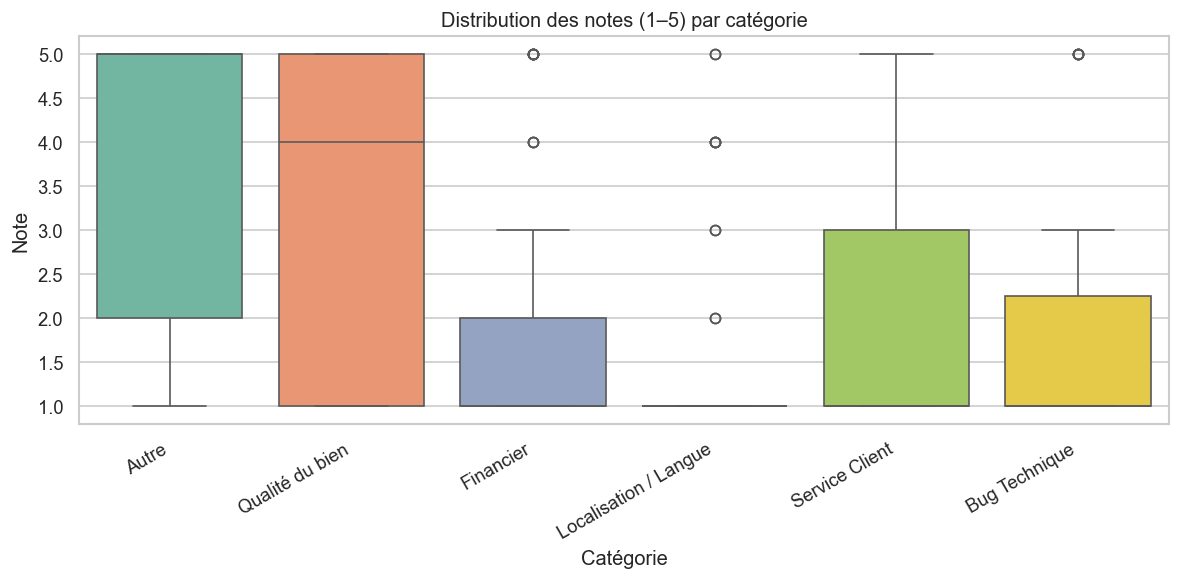

,count,mean,median,std
Catégorie,,,,
Autre,204,3.696,5,1.683
Bug Technique,28,2,1,1.54
Financier,59,1.847,1,1.412
Localisation / Langue,46,1.565,1,1.186
Qualité du bien,73,3.055,4,1.848
Service Client,31,1.806,1,1.352


In [10]:
ordre_cat = df["Catégorie"].value_counts().index.tolist()
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Catégorie", y="note", order=ordre_cat, palette="Set2")
plt.title("Distribution des notes (1–5) par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Note")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

df.groupby("Catégorie", observed=True)["note"].agg(["count", "mean", "median", "std"]).round(3)

## 8. Longueur des commentaires (proxy d’effort / détail)

Nombre de caractères (et de mots) par avis : utile pour détecter des avis « courts » vs « argumentés ». Corrélation de **Spearman** entre longueur et note (ordinales) — interprétation prudente.


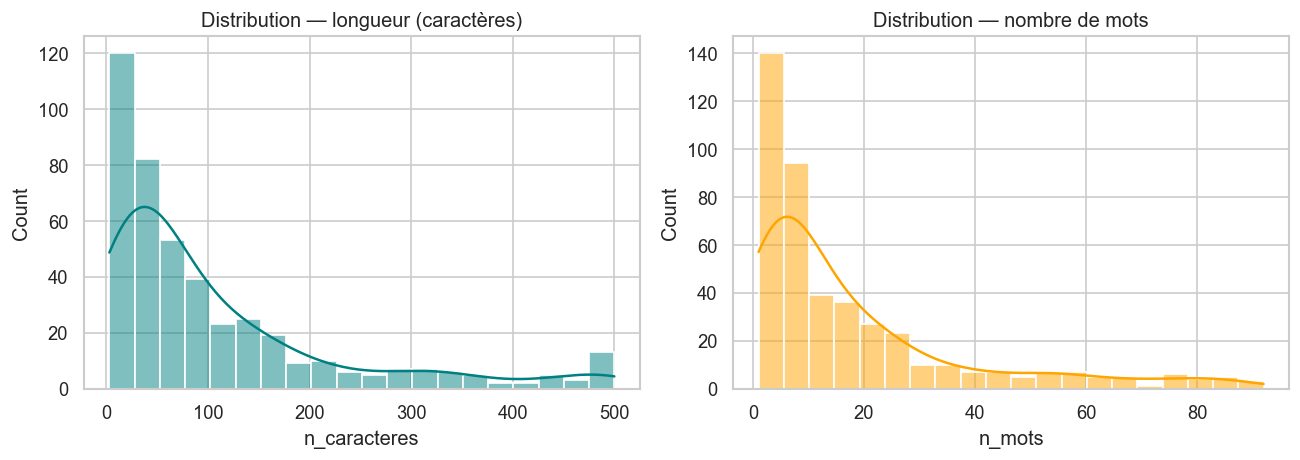

Corrélation de Spearman (caractères vs note) : -0.4751


,n_caracteres,n_mots
Catégorie,,
Autre,26,4
Bug Technique,82.5,11.5
Financier,230,35
Localisation / Langue,71.5,12.5
Qualité du bien,106,16
Service Client,177,26


In [11]:
df["n_caracteres"] = df["texte"].str.len()
df["n_mots"] = df["texte"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["n_caracteres"], bins=20, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution — longueur (caractères)")
sns.histplot(df["n_mots"], bins=20, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Distribution — nombre de mots")
plt.tight_layout()
plt.show()

# Spearman : monotone entre longueur et note
rho = df[["n_caracteres", "note"]].corr(method="spearman").iloc[0, 1]
print(f"Corrélation de Spearman (caractères vs note) : {rho:.4f}")

df.groupby("Catégorie", observed=True)[["n_caracteres", "n_mots"]].median().round(1)

## 9. Courbe de Pareto (catégories)

Les **k** premières catégories cumulent quelle part du volume ? Aide à trancher « vital few » en revue produit.


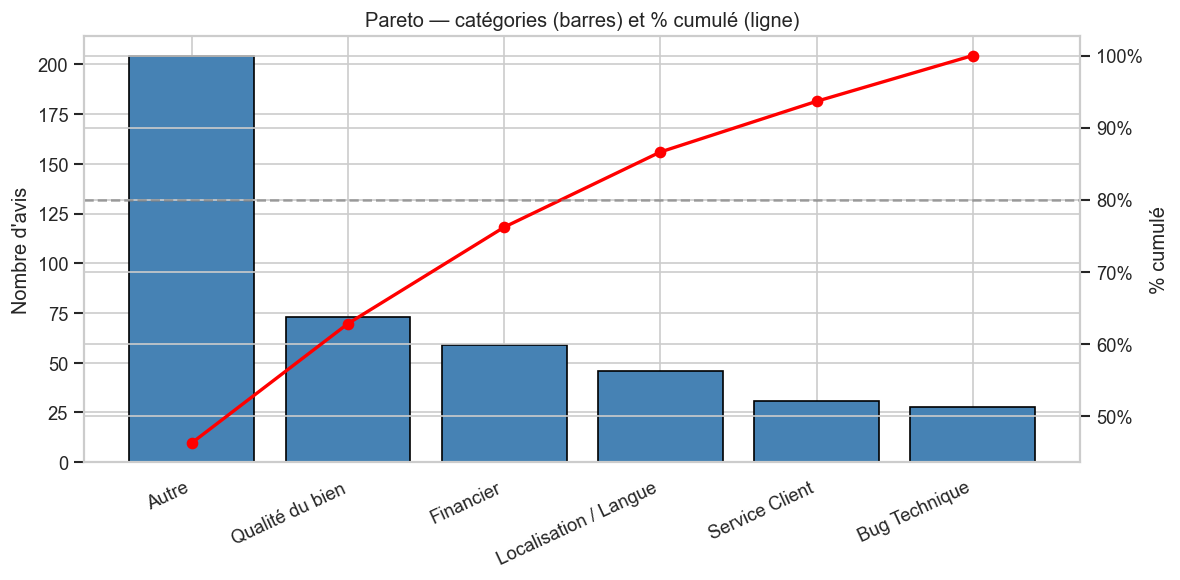

,Catégorie,Effectif,% cumulé
0,Autre,204,46.26
1,Qualité du bien,73,62.81
2,Financier,59,76.19
3,Localisation / Langue,46,86.62
4,Service Client,31,93.65
5,Bug Technique,28,100


In [12]:
cat_sorted = df["Catégorie"].value_counts().sort_values(ascending=False)
cum_pct = (100 * cat_sorted.cumsum() / N).round(2)

pareto = pd.DataFrame(
    {"Catégorie": cat_sorted.index, "Effectif": cat_sorted.values, "% cumulé": cum_pct.values}
)

fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(cat_sorted))
ax1.bar(x, cat_sorted.values, color="steelblue", edgecolor="black", label="Effectif")
ax1.set_xticks(x)
ax1.set_xticklabels(cat_sorted.index, rotation=25, ha="right")
ax1.set_ylabel("Nombre d'avis")
ax1.set_title("Pareto — catégories (barres) et % cumulé (ligne)")

ax2 = ax1.twinx()
ax2.plot(x, cum_pct.values, color="red", marker="o", linewidth=2, label="% cumulé")
ax2.set_ylabel("% cumulé")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax2.axhline(80, color="gray", linestyle="--", alpha=0.7, label="80 %")
fig.tight_layout()
plt.show()

pareto

## 10. Exports pour Power BI (optionnel)

Fichiers dérivés dans `data/` :  
- `synthese_categories.csv` : une ligne par catégorie avec effectif et %.  
- `crosstab_categorie_gravite.csv` : effectifs croisés (sans marges).

Tu peux aussi **uniquement** connecter Power BI à `avis_enrichis.csv` et recréer les mesures DAX à partir de la section 3.


In [13]:
out_dir = Path("data")
out_dir.mkdir(parents=True, exist_ok=True)

synthese = pd.DataFrame(
    {
        "Catégorie": cat_sorted.index,
        "Effectif": cat_sorted.values,
        "pct_total": (100 * cat_sorted.values / N).round(4),
        "pct_cumule": cum_pct.values,
    }
)
synthese.to_csv(out_dir / "synthese_categories.csv", index=False, encoding="utf-8")

ct_body.to_csv(out_dir / "crosstab_categorie_gravite.csv", encoding="utf-8")

print("Écrit :", (out_dir / "synthese_categories.csv").resolve())
print("Écrit :", (out_dir / "crosstab_categorie_gravite.csv").resolve())

Écrit : /Users/ngsanogo/Dev/abritel/data/synthese_categories.csv
Écrit : /Users/ngsanogo/Dev/abritel/data/crosstab_categorie_gravite.csv


## 11. Limites méthodologiques (à citer en soutenance)

1. **Échantillon** : les avis sont ceux renvoyés par `google-play-scraper` à l’instant T ; ce n’est pas l’historique complet du store.  
2. **Catégorisation lexicale** : biais de rappel / précision ; une partie des « Autre » peut masquer un thème non listé dans les mots-clés.  
3. **Gravité** : heuristique (mots forts + note 1) ; ne remplace pas une analyse qualitative humaine sur un sous-échantillon.  
4. **Causalité** : corrélation temporelle ou Spearman **n’implique pas** de lien causal produit.

---
*Notebook prêt pour réplication des mesures dans Power BI (même définitions, même fichier source).*
